# 04 · TabNet V2 (정형 특화 딥러닝, 제대로 재실험)

> TabNet은 정형 데이터용 딥러닝(sequential attention으로 피처를 단계별 선택).
> 기존 0.093은 작은 서브샘플+기본설정이라 과소평가였다. 여기선 공정하게:
> v2 피처 + 더 큰 서브샘플(15만) + 더 많은 epoch + early stopping(AUC) + 클래스 균형(weights=1).
> 그리고 **TabNet feature importance**를 뽑아 트리(SHAP/중요변수)와 비교한다.
> 기대: 0.093 -> 0.15~0.22 (그래도 XGB_v2_tuned 0.296 아래일 가능성 큼 - 정직하게 기록).

## 0. 환경 설정 + 데이터

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pytorch_tabnet.tab_model import TabNetClassifier

from utils import set_seed, compute_metrics, log_result, load_processed
set_seed(42)

PROJECT_ROOT = Path(r"C:\Users\Administrator\Desktop\딥러닝응용\TermProject")
OUT_DIR    = PROJECT_ROOT / "processed_v2"
NB_DIR     = PROJECT_ROOT / "notebooks_v2"
RESULTS_V2 = NB_DIR / "results_v2.csv"

train_df, val_df, test_df = load_processed(OUT_DIR)
TARGET = "went_on_backorder"
feature_cols = [c for c in train_df.columns if c != TARGET]
X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df[TARGET].values.astype("int64")
X_val   = val_df[feature_cols].values.astype("float32")
y_val   = val_df[TARGET].values.astype("int64")
print("피처:", len(feature_cols))

피처: 42


## 1. 학습용 서브샘플 (CPU 대응)
TabNet은 CPU에서 무겁다. 기존(10만)보다 키운 15만 샘플(비율 유지)로 학습, 평가는 val 전체.
서브샘플이지만 epoch와 early stopping으로 충분히 학습시킨다.

In [2]:
SUBSAMPLE = 150000
rng = np.random.default_rng(42)
sel = rng.choice(len(X_train), size=SUBSAMPLE, replace=False)
X_fit, y_fit = X_train[sel], y_train[sel]
print("학습 샘플:", len(sel), " 양성:", int(y_fit.sum()))

학습 샘플: 150000  양성: 1007


## 2. TabNet 학습 (불균형 + early stopping)
- weights=1: 소수 클래스 자동 균형.
- eval_metric=auc + patience: val AUC가 더 안 오르면 멈춤(과적합 방지 + 시간 절약).

In [3]:
set_seed(42)
clf = TabNetClassifier(seed=42, verbose=1)
clf.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=30,
    patience=8,
    batch_size=16384,
    virtual_batch_size=1024,
    weights=1,
)

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.62875 | val_auc: 0.86347 |  0:00:10s


epoch 1  | loss: 0.39702 | val_auc: 0.88045 |  0:00:21s


epoch 2  | loss: 0.36185 | val_auc: 0.89936 |  0:00:31s


epoch 3  | loss: 0.34002 | val_auc: 0.89877 |  0:00:41s


...

epoch 16 | loss: 0.24596 | val_auc: 0.91808 |  0:02:58s


epoch 17 | loss: 0.24261 | val_auc: 0.91719 |  0:03:09s


epoch 18 | loss: 0.2428  | val_auc: 0.92088 |  0:03:19s


epoch 19 | loss: 0.24439 | val_auc: 0.92286 |  0:03:30s

Early stopping occurred at epoch 19 with best_epoch = 11 and best_val_auc = 0.92377


C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## 3. 평가 + 기록 + 확률 저장

In [4]:
val_prob = clf.predict_proba(X_val)[:, 1]
m = compute_metrics(y_val, val_prob)
log_result("TabNet_v2", m, path=str(RESULTS_V2))
np.save(NB_DIR / "tabnet_v2_val_prob.npy", val_prob)
print("TabNet_v2", m)
print("기존 TabNet 0.0932 대비:", round(m["PR_AUC"] - 0.0932, 4))

TabNet_v2 {'PR_AUC': 0.1016, 'ROC_AUC': 0.9238, 'Recall': 0.915, 'Precision': 0.0279, 'F1': 0.0541, 'threshold': 0.5}
기존 TabNet 0.0932 대비: 0.0084


## 4. TabNet feature importance (해석)
TabNet이 중요하게 본 피처. 트리(XGBoost/LightGBM)의 중요 변수와 같은 걸 보는지 비교(보고서용).

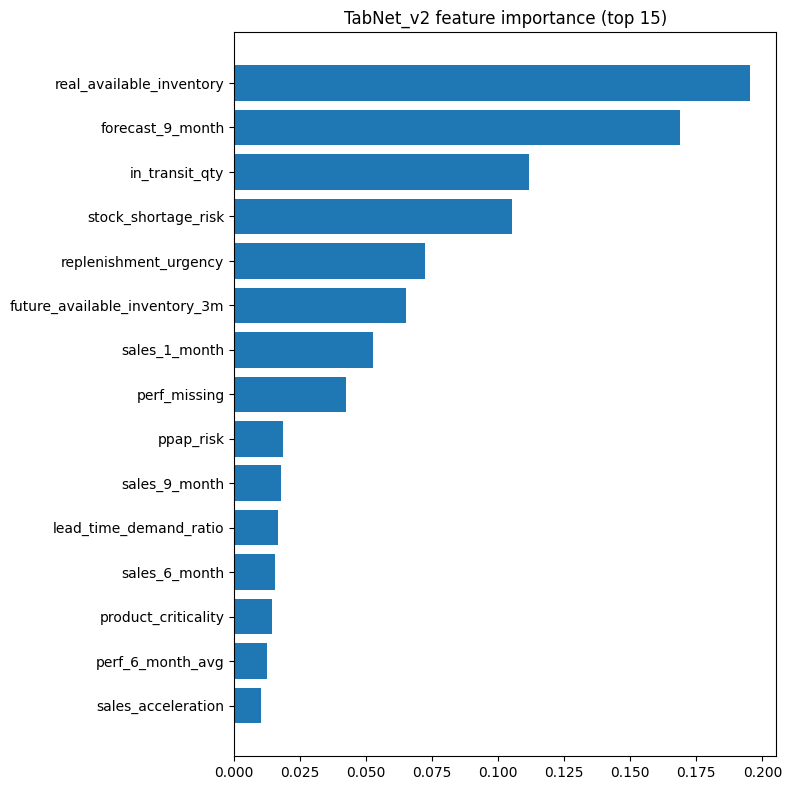

TabNet 상위 10 피처:
  real_available_inventory     0.1955
  forecast_9_month             0.1687
  in_transit_qty               0.1116
  stock_shortage_risk          0.1052
  replenishment_urgency        0.0721
  future_available_inventory_3m 0.0651
  sales_1_month                0.0525
  perf_missing                 0.0425
  ppap_risk                    0.0185
  sales_9_month                0.0178


In [5]:
imp = clf.feature_importances_
order = np.argsort(imp)[::-1]
names = [feature_cols[i] for i in order]

plt.figure(figsize=(8, 8))
plt.barh(names[::-1][-15:], imp[order][::-1][-15:])
plt.title("TabNet_v2 feature importance (top 15)")
plt.tight_layout()
plt.show()

print("TabNet 상위 10 피처:")
for i in order[:10]:
    print(f"  {feature_cols[i]:28s} {imp[i]:.4f}")

## 5. 결과 비교 (results_v2.csv)

In [6]:
res = pd.read_csv(RESULTS_V2).drop_duplicates(subset="model", keep="last").sort_values("PR_AUC", ascending=False)
res[["model", "PR_AUC", "ROC_AUC", "Recall", "Precision", "F1"]]

,model,PR_AUC,ROC_AUC,Recall,Precision,F1
1,XGB_v2_tuned,0.2959,0.9687,0.8699,0.0861,0.1566
3,LGBM_v2_tuned,0.2636,0.9666,0.8907,0.0734,0.1356
0,XGB_v2_base,0.2418,0.9616,0.8911,0.0600,0.1124
2,LGBM_v2_base,0.2246,0.9568,0.8831,0.0551,0.1037
4,MLP_v2_plain_BCE,0.1982,0.9409,0.0000,0.0000,0.0000
8,MLP_v2_focal_batchnorm,0.1953,0.9476,0.1633,0.3306,0.2187
6,MLP_v2_focal,0.1952,0.9443,0.1651,0.3391,0.2221
9,MLP_v2_SMOTE,0.1924,0.9469,0.5440,0.1531,0.2389
7,MLP_v2_focal_dropout,0.1850,0.9427,0.1067,0.3691,0.1655
5,MLP_v2_weighted,0.1766,0.9464,0.8588,0.0515,0.0972


---
### 결론 (실행 후 해석)
- TabNet_v2 vs 기존 0.093: v2 피처 + 제대로 학습이 얼마나 끌어올렸나.
- TabNet_v2 vs XGB_v2_tuned 0.296: 못 넘으면 정직하게 기록(정형 특화 DL도 GBDT는 잘 못 이김).
- feature importance: TabNet과 트리가 같은 변수(재고부족/지역백오더 등)를 중요하게 보는지 = 모델 간 해석 일치 여부(보고서 가치).
- 핵심: TabNet의 가치는 성능보다 '딥러닝 다양성 + 해석'이다.